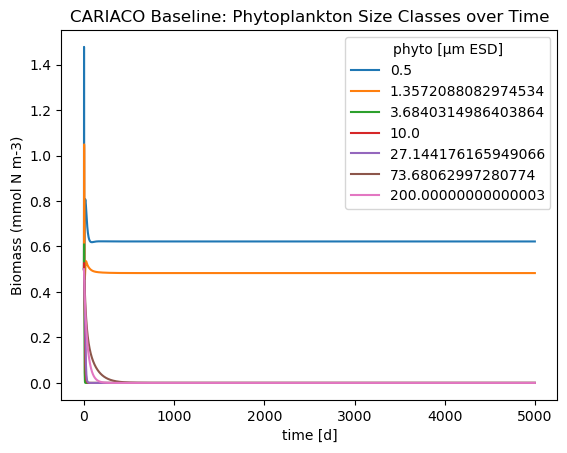

[INFO] Initial state dimension: 15
[INFO] Initial state: [5.16026588e-002 6.22110862e-001 4.83080971e-001 0.00000000e+000
 0.00000000e+000 0.00000000e+000 7.85885990e-020 2.87170616e-045
 8.27453755e-001 4.56675353e-001 8.21933926e-001 4.82400810e-001
 4.07724628e-001 3.70889875e-069 3.13723528e-137]
[INFO] Steady state found with residual norm: 1.61e-16
  Steady state: [ 5.16027212e-002  6.22110810e-001  4.83080956e-001 -3.85509601e-029
 -1.03974887e-028  2.04959582e-028  6.40255695e-033  1.11656203e-059
  8.27453760e-001  4.56675353e-001  8.21933926e-001  4.82400810e-001
  4.07724627e-001  2.73320346e-082  2.67669537e-151]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 15 eigenvalues
Steady State Phyto Spectrum (mmol N m-3): [ 6.22110810e-01  4.83080956e-01 -3.85509601e-29 -1.03974887e-28
  2.04959582e-28  6.40255695e-33  1.11656203e-59]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from npxzxf_models import run_model_test, run_model_test_stability

def get_cariaco_base_inputs():
    """Returns the base dictionary of CARIACO physical forcings."""
    return {
        'N0__value': 5.5564,              # Mean sub-euphotic NO3 (50-70m)
        'Inflow__rate': 0.016786,         # Calculated dilution rate (d-1)
        'Nutrient__value_init': 2.0158,   # Mean euphotic NO3 (0-50m) to speed up convergence
        'FishForcing__value': 0.1         # Placeholder: will be tuned for High/Low fish states
    }

def run_cariaco_ivp(tuning_params=None, time_steps=5000):
    """
    Run the CARIACO model over time to visualize transient dynamics 
    or check for limit cycles/oscillations.
    """
    inputs = get_cariaco_base_inputs()
    if tuning_params:
        inputs.update(tuning_params)
        
    return run_model_test(i=inputs, time=np.arange(0, time_steps))

def run_cariaco_steady_state(tuning_params=None):
    """
    Run the CARIACO model directly to steady-state. 
    Ideal for fast iterative fitting routines.
    """
    inputs = get_cariaco_base_inputs()
    if tuning_params:
        inputs.update(tuning_params)
        
    return run_model_test_stability(i=inputs)

    # 1. Run the baseline to see what the default parameters yield under CARIACO forcing
out_transient = run_cariaco_ivp(time_steps=5000)

# Plot Phytoplankton Biomass over time to ensure it reaches steady state
out_transient.Phytoplankton__biomass.plot.line(x='time')
plt.title('CARIACO Baseline: Phytoplankton Size Classes over Time')
plt.ylabel('Biomass (mmol N m-3)')
plt.show()

# --- NEW: Extract average of the last 1000 days for initial conditions ---
# Using xarray's .isel to slice the last 1000 steps and .mean() to average
n_init_avg = out_transient.Nutrient__value.isel(time=slice(-1000, None)).mean(dim='time').values
p_init_avg = out_transient.Phytoplankton__biomass.isel(time=slice(-1000, None)).mean(dim='time').values
z_init_avg = out_transient.Zooplankton__biomass.isel(time=slice(-1000, None)).mean(dim='time').values

# Bundle the new initial conditions into a dictionary
ivp_initial_conditions = {
    'Nutrient__value_init': float(n_init_avg), # Ensure scalar for N
    'Phytoplankton__biomass_init': p_init_avg,
    'Zooplankton__biomass_init': z_init_avg
}

# 2. Run the steady-state solver directly, seeded with the IVP averages
out_ss = run_cariaco_steady_state(tuning_params=ivp_initial_conditions)

# Extract the final steady-state size spectrum for Phytoplankton
# (This is the vector you will eventually compare against your pigment data)
ss_phyto_spectrum = out_ss.Phytoplankton__biomass.isel(time=-1).values
print("Steady State Phyto Spectrum (mmol N m-3):", ss_phyto_spectrum)

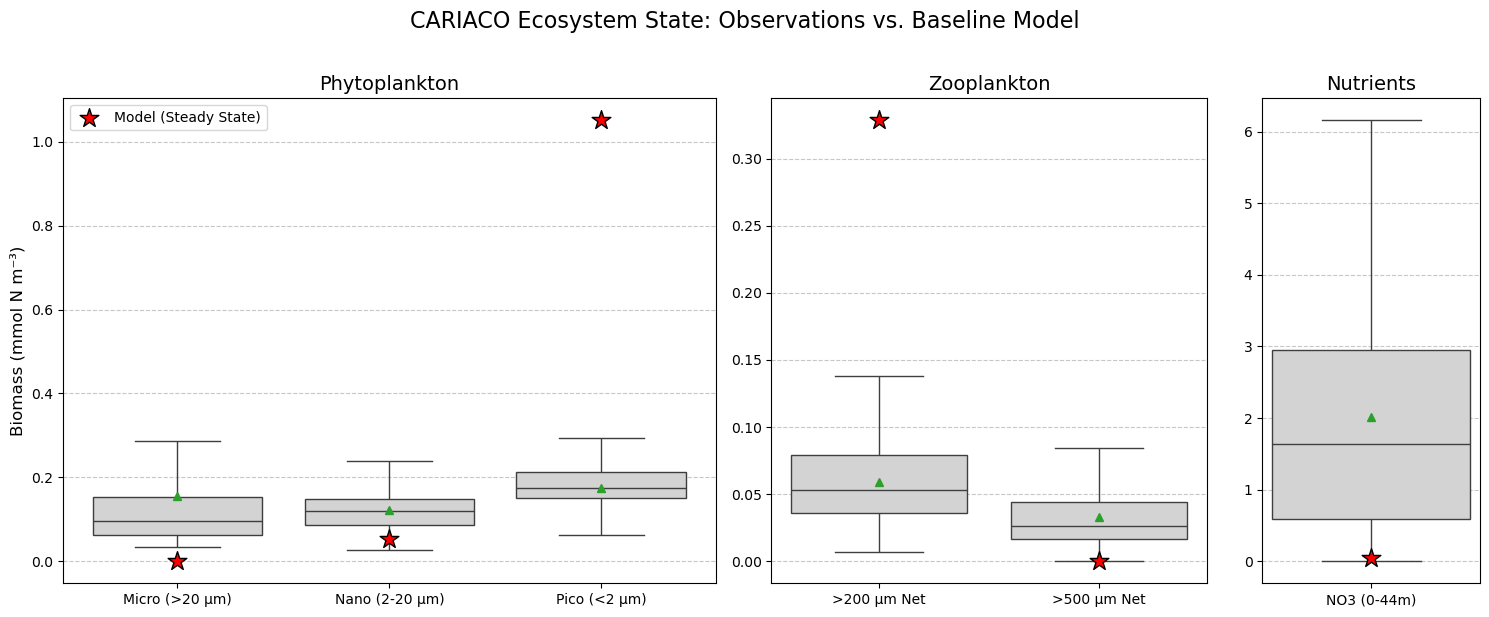


 NUMERICAL SUMMARY: MODEL VS OBSERVATIONS (mmol N m⁻³)
            Component  Obs_Median  Obs_Mean  Model_SS  Diff_(Model-Mean)
Phyto: Micro (>20 µm)     0.09544   0.15627   0.00000           -0.15627
Phyto: Nano (2-20 µm)     0.11883   0.12162   0.05397           -0.06765
  Phyto: Pico (<2 µm)     0.17513   0.17506   1.05122            0.87616
     Zoo: >200 µm Net     0.05304   0.05934   0.32857            0.26923
     Zoo: >500 µm Net     0.02617   0.03280   0.00000           -0.03280
        Nutrient: NO3     1.63575   2.01581   0.05160           -1.96421



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from npxzxf_models import phyto_esd, zoo_esd

# =============================================================================
# 1. LOAD AND PREP DATA
# =============================================================================

file_path = "../DATA/processed/CARIACO_EnvData_combined.csv"
cariaco_data = pd.read_csv(file_path)

# Parameters for unit conversion
euphotic_depth = 44.92   # m
c_to_chl = 50.0          # mg C : mg Chl
c_to_dw = 0.4            # mg C : mg Dry Weight (Zooplankton assumption ~40%)
redfield_n_c = 16 / 106  # mmol N : mmol C

# --- A. Phytoplankton (mg Chl m-2 -> mmol N m-3) ---
phyto_cols = ['micro_abs', 'nano_abs', 'pico_abs']
phyto_data = cariaco_data[phyto_cols].dropna().copy()

for col in phyto_cols:
    # (Areal / Depth) * C:Chl / atomic_weight_C * Redfield
    phyto_data[col] = (phyto_data[col] / euphotic_depth) * c_to_chl / 12.01 * redfield_n_c

phyto_data.columns = ['Micro (>20 µm)', 'Nano (2-20 µm)', 'Pico (<2 µm)']

# --- B. Zooplankton (mg DW m-3 -> mmol N m-3) ---
# REVISED: Using raw cumulative catches directly
zoo_data = pd.DataFrame()
zoo_data['>200 µm Net'] = cariaco_data['BIOMASS_200']
zoo_data['>500 µm Net'] = cariaco_data['BIOMASS_500']
zoo_data = zoo_data.dropna().copy()

for col in zoo_data.columns:
    # mg DW * C:DW / atomic_weight_C * Redfield
    zoo_data[col] = (zoo_data[col] * c_to_dw) / 12.01 * redfield_n_c

# --- C. Nutrients (Dynamic Euphotic Zone: Already in µmol/L == mmol/m3) ---
# Load the specific CSV you just generated in R
nut_data = pd.read_csv("DataAnalysis/NO3_euphotic_dynamic.csv")

# Extract the NO3 column and drop NAs
nut_data = nut_data[['NO3_euphotic']].dropna().copy()

# Rename it for the plot title
nut_data.columns = [f'NO3 (0-{int(euphotic_depth)}m)'] 
# (Note: If mean_euphotic_depth isn't defined in your Python script yet, 
# you can just hardcode the string to 'NO3 (Euphotic)' for now)

import numpy as np

# =============================================================================
# FRACTIONAL OVERLAP UTILITIES
# =============================================================================

def get_log_bin_edges(centers):
    """Calculates the N+1 bin edges for N logarithmically spaced centers."""
    q = centers[1] / centers[0]
    half_step = np.sqrt(q)
    
    edges = np.zeros(len(centers) + 1)
    edges[0] = centers[0] / half_step
    edges[1:] = centers * half_step
    return edges

def get_fraction_in_range(lower, upper, target_min, target_max):
    """
    Calculates the fraction of a log-spaced bin [lower, upper] 
    that falls within a desired target range [target_min, target_max].
    """
    # Find the actual overlapping window
    overlap_min = max(lower, target_min)
    overlap_max = min(upper, target_max)
    
    # If the bin is completely outside the target range
    if overlap_min >= overlap_max:
        return 0.0
    
    # Calculate the fractional overlap in log10 space
    return (np.log10(overlap_max) - np.log10(overlap_min)) / (np.log10(upper) - np.log10(lower))

# =============================================================================
# MODEL AGGREGATION (UPDATED FOR PHYTO & ZOO)
# =============================================================================

def aggregate_model_state(ss_phyto, ss_zoo, ss_nut, p_esd, z_esd):
    """Groups the model output using fractional overlaps for BOTH Phyto and Zoo."""
    
    # --- Phytoplankton ---
    p_edges = get_log_bin_edges(p_esd)
    
    micro_n = 0.0
    nano_n = 0.0
    pico_n = 0.0
    
    for i in range(len(p_esd)):
        lower = p_edges[i]
        upper = p_edges[i+1]
        biomass = ss_phyto[i]
        
        # We use 1e-9 for "zero" and 1e9 for "infinity" to avoid log(0) errors
        pico_n += biomass * get_fraction_in_range(lower, upper, 1e-9, 2.0)
        nano_n += biomass * get_fraction_in_range(lower, upper, 2.0, 20.0)
        micro_n += biomass * get_fraction_in_range(lower, upper, 20.0, 1e9)
        
    model_phyto = [micro_n, nano_n, pico_n]
    
    # --- Zooplankton ---
    z_edges = get_log_bin_edges(z_esd)
    
    zoo_gt_200 = 0.0
    zoo_gt_500 = 0.0
    
    for i in range(len(z_esd)):
        lower = z_edges[i]
        upper = z_edges[i+1]
        biomass = ss_zoo[i]
        
        # Calculate cumulative overlaps exactly matching the nets
        zoo_gt_200 += biomass * get_fraction_in_range(lower, upper, 200.0, 1e9)
        zoo_gt_500 += biomass * get_fraction_in_range(lower, upper, 500.0, 1e9)
        
    model_zoo = [zoo_gt_200, zoo_gt_500]
    
    return model_phyto, model_zoo, [float(ss_nut)]

    
# Extract the final steady-state values for ALL components using .isel(time=-1)
ss_phyto_spectrum = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo_spectrum = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nutrient = out_ss.Nutrient__value.isel(time=-1).values

# Now group the model output
model_p, model_z, model_n = aggregate_model_state(
    ss_phyto_spectrum, ss_zoo_spectrum, ss_nutrient, phyto_esd, zoo_esd
)
# =============================================================================
# 3. PLOTTING
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 2, 1]})

# Plot settings
box_palette = "lightgray"
model_marker = dict(marker='*', color='red', s=200, edgecolor='black', zorder=5, label='Model (Steady State)')

# 1. Phytoplankton
sns.boxplot(data=phyto_data, ax=axes[0], color=box_palette, showmeans=True, showfliers=False)
axes[0].scatter(range(len(model_p)), model_p, **model_marker)
axes[0].set_title('Phytoplankton', fontsize=14)
axes[0].set_ylabel('Biomass (mmol N m⁻³)', fontsize=12)

# 2. Zooplankton
sns.boxplot(data=zoo_data, ax=axes[1], color=box_palette, showmeans=True, showfliers=False)
axes[1].scatter(range(len(model_z)), model_z, **model_marker)
axes[1].set_title('Zooplankton', fontsize=14)

# 3. Nutrients
sns.boxplot(data=nut_data, ax=axes[2], color=box_palette, showmeans=True, showfliers=False)
axes[2].scatter([0], model_n, **model_marker)
axes[2].set_title('Nutrients', fontsize=14)


USE_LOG_SCALE = False  # Change to False to revert to linear scale
# Global formatting
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # --- APPLY LOG SCALE IF TOGGLED ---
    if USE_LOG_SCALE:
        ax.set_yscale('log')
        
    if ax == axes[0]:
        ax.legend()

plt.suptitle('CARIACO Ecosystem State: Observations vs. Baseline Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =============================================================================
# 4. NUMERIC OUTPUT SUMMARY
# =============================================================================
print("\n" + "="*65)
print(" NUMERICAL SUMMARY: MODEL VS OBSERVATIONS (mmol N m⁻³)")
print("="*65)

# Extract means and medians from the dataframes
obs_means = [
    phyto_data['Micro (>20 µm)'].mean(),
    phyto_data['Nano (2-20 µm)'].mean(),
    phyto_data['Pico (<2 µm)'].mean(),
    zoo_data['>200 µm Net'].mean(),
    zoo_data['>500 µm Net'].mean(),
    nut_data.iloc[:, 0].mean()  # Uses iloc to avoid hardcoded column names
]

obs_medians = [
    phyto_data['Micro (>20 µm)'].median(),
    phyto_data['Nano (2-20 µm)'].median(),
    phyto_data['Pico (<2 µm)'].median(),
    zoo_data['>200 µm Net'].median(),
    zoo_data['>500 µm Net'].median(),
    nut_data.iloc[:, 0].median()
]

# Flatten the model output arrays into a single list
model_vals = model_p + model_z + model_n

labels = [
    'Phyto: Micro (>20 µm)', 
    'Phyto: Nano (2-20 µm)', 
    'Phyto: Pico (<2 µm)',
    'Zoo: >200 µm Net',
    'Zoo: >500 µm Net',
    'Nutrient: NO3'
]

# Build a summary DataFrame for clean printing
summary_df = pd.DataFrame({
    'Component': labels,
    'Obs_Median': obs_medians,
    'Obs_Mean': obs_means,
    'Model_SS': model_vals
})

# Add a quick difference column to highlight the biggest gaps
summary_df['Diff_(Model-Mean)'] = summary_df['Model_SS'] - summary_df['Obs_Mean']

# Print with fixed floating point formatting so it's easy to read
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print("="*65 + "\n")

In [8]:
# =============================================================================
# 4. NUMERIC OUTPUT SUMMARY
# =============================================================================
print("\n" + "="*65)
print(" NUMERICAL SUMMARY: MODEL VS OBSERVATIONS (mmol N m⁻³)")
print("="*65)

# Extract means and medians from the dataframes
obs_means = [
    phyto_data['Micro (>20 µm)'].mean(),
    phyto_data['Nano (2-20 µm)'].mean(),
    phyto_data['Pico (<2 µm)'].mean(),
    zoo_data['>200 µm Net'].mean(),
    zoo_data['>500 µm Net'].mean(),
    nut_data.iloc[:, 0].mean()  # Uses iloc to avoid hardcoded column names
]

obs_medians = [
    phyto_data['Micro (>20 µm)'].median(),
    phyto_data['Nano (2-20 µm)'].median(),
    phyto_data['Pico (<2 µm)'].median(),
    zoo_data['>200 µm Net'].median(),
    zoo_data['>500 µm Net'].median(),
    nut_data.iloc[:, 0].median()
]

# Flatten the model output arrays into a single list
model_vals = model_p + model_z + model_n

labels = [
    'Phyto: Micro (>20 µm)', 
    'Phyto: Nano (2-20 µm)', 
    'Phyto: Pico (<2 µm)',
    'Zoo: >200 µm Net',
    'Zoo: >500 µm Net',
    'Nutrient: NO3'
]

# Build a summary DataFrame for clean printing
summary_df = pd.DataFrame({
    'Component': labels,
    'Obs_Median': obs_medians,
    'Obs_Mean': obs_means,
    'Model_SS': model_vals
})

# Add a quick difference column to highlight the biggest gaps
summary_df['Diff_(Model-Mean)'] = summary_df['Model_SS'] - summary_df['Obs_Mean']

# Print with fixed floating point formatting so it's easy to read
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print("="*65 + "\n")


 NUMERICAL SUMMARY: MODEL VS OBSERVATIONS (mmol N m⁻³)
            Component  Obs_Median  Obs_Mean  Model_SS  Diff_(Model-Mean)
Phyto: Micro (>20 µm)     0.09544   0.15627   0.00000           -0.15627
Phyto: Nano (2-20 µm)     0.11883   0.12162   0.05397           -0.06765
  Phyto: Pico (<2 µm)     0.17513   0.17506   1.05122            0.87616
     Zoo: >200 µm Net     0.05304   0.05934   0.32857            0.26923
     Zoo: >500 µm Net     0.02617   0.03280   0.00000           -0.03280
        Nutrient: NO3     1.63575   2.01581   0.05160           -1.96421



In [60]:
ss_nutrient

array(0.02688732)